# Parte 2 · Comparación de arquitecturas preentrenadas (feature extraction + linear probe)

**Visión por Computadora II · CEIA · FIUBA**

Como entrenamos en **CPU**, el *fine-tuning* completo de varias arquitecturas es caro. Este notebook hace una primera comparación barata y rigurosa:

1. Congelamos (*frozen*) cada backbone preentrenado en ImageNet y extraemos **una sola vez** los embeddings de todo el dataset (se cachean en `cache/`).
2. Entrenamos sobre esos embeddings un **linear head** (*linear probe*, segundos), con y sin ponderación por clase para el desbalance.
3. Comparamos arquitecturas por accuracy, **balanced accuracy y macro-F1** (el desbalance es 14×), y analizamos por clase y con matriz de confusión.

Esto mide qué tan buenas son las representaciones de ImageNet *tal cual* para hojas de plantas y da un baseline contra el cual medir el fine-tuning (notebook 03). Los hiperparámetros se eligen con **val**; **test** se reporta una sola vez al final.

## 0. Configuración

In [1]:
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

from common import *

torch.set_num_threads(os.cpu_count())
torch.manual_seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid")
RESULTS_DIR = ROOT / "results"; RESULTS_DIR.mkdir(exist_ok=True)

MODELS = ["mobilenet_v3_small", "mobilenet_v3_large", "efficientnet_b0", "resnet18"]
# MODELS += ["resnet50"]   # opcional: ~1 h de extracción en CPU

df, classes = load_split()
print(f"{len(df):,} imágenes | {len(classes)} clases | modelos: {MODELS}")
print(df["split"].value_counts().to_dict())

16,306 imágenes | 13 clases | modelos: ['mobilenet_v3_small', 'mobilenet_v3_large', 'efficientnet_b0', 'resnet18']
{'train': 11646, 'test': 2330, 'val': 2330}


## 1. Extracción de embeddings (una sola vez por modelo)

Cada imagen pasa por el frozen backbone con el pipeline determinístico `eval_tf` (sin augmentation). Los resultados quedan en `cache/feats_<modelo>.npz`, así que volver a correr esta celda es instantáneo.

In [2]:
feats, rows = {}, []
for name in MODELS:
    X, secs = get_features(name, df)
    assert len(X) == len(df)
    feats[name] = X
    n_params = sum(p.numel() for p in build_backbone(name)[0].parameters()) / 1e6
    rows.append({"modelo": name, "dim": X.shape[1], "params (M)": round(n_params, 1),
                 "img/s (extracción)": round(len(df) / secs, 1), "min": round(secs / 60, 1)})
pd.DataFrame(rows).set_index("modelo")

,dim,params (M),img/s (extracción),min
modelo,,,,
mobilenet_v3_small,576,0.9,63.7,4.3
mobilenet_v3_large,960,3.0,33.7,8.1
efficientnet_b0,1280,4.0,21.1,12.9
resnet18,512,11.2,41.6,6.5


## 2. Linear head sobre los embeddings

Estandarizamos los embeddings con media/desvío de **train** y entrenamos un linear head (una sola capa `Linear`) con AdamW. Elegimos la mejor época por macro-F1 en **val** (early stopping). Comparamos entropía cruzada estándar contra ponderada por frecuencia inversa de clase.

In [3]:
y = df["y"].values
idx = {s: np.where(df["split"].values == s)[0] for s in ["train", "val", "test"]}

def class_weights(y_train, n_classes):
    cnt = np.bincount(y_train, minlength=n_classes)
    w = len(y_train) / (n_classes * cnt)
    return torch.tensor(w, dtype=torch.float32)

def train_head(X, y, weighted, epochs=60, lr=3e-3, wd=1e-3, bs=256, seed=SEED):
    torch.manual_seed(seed)
    mu, sd = X[idx["train"]].mean(0), X[idx["train"]].std(0) + 1e-6
    Z = torch.tensor((X - mu) / sd, dtype=torch.float32)
    Y = torch.tensor(y)
    tr, va = idx["train"], idx["val"]
    head = nn.Linear(Z.shape[1], len(classes))
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights(y[tr], len(classes)) if weighted else None)
    best = (-1, None, 0)
    for ep in range(epochs):
        head.train()
        perm = torch.tensor(np.random.RandomState(seed + ep).permutation(tr))
        for i in range(0, len(perm), bs):
            b = perm[i:i + bs]
            opt.zero_grad(); loss_fn(head(Z[b]), Y[b]).backward(); opt.step()
        sched.step()
        head.eval()
        with torch.no_grad():
            f1 = metrics(y[va], head(Z[va]).argmax(1).numpy())["macro_f1"]
        if f1 > best[0]:
            best = (f1, {k: v.clone() for k, v in head.state_dict().items()}, ep + 1)
    head.load_state_dict(best[1]); head.eval()
    with torch.no_grad():
        logits = head(Z).numpy()
    return logits, best[2]

results, preds = [], {}
for name in MODELS:
    for weighted in (False, True):
        t0 = time.time()
        logits, best_ep = train_head(feats[name], y, weighted)
        pred = logits.argmax(1)
        preds[(name, weighted)] = pred
        mv, mt = metrics(y[idx["val"]], pred[idx["val"]]), metrics(y[idx["test"]], pred[idx["test"]])
        results.append({"modelo": name, "loss ponderada": weighted, "mejor época": best_ep,
                        **{f"val_{k}": v for k, v in mv.items()}, **{f"test_{k}": v for k, v in mt.items()},
                        "seg": round(time.time() - t0, 1)})
res = pd.DataFrame(results)
res.to_csv(RESULTS_DIR / "linear_probe.csv", index=False)
res.round(4)

,modelo,loss ponderada,mejor época,val_accuracy,val_balanced_acc,val_macro_f1,test_accuracy,test_balanced_acc,test_macro_f1,seg
0,mobilenet_v3_small,False,28,0.9614,0.9622,0.9585,0.9700,0.9722,0.9721,2.4
1,mobilenet_v3_small,True,39,0.9605,0.9657,0.9560,0.9721,0.9761,0.9726,2.3
2,mobilenet_v3_large,False,24,0.9657,0.9613,0.9633,0.9687,0.9705,0.9703,2.7
3,mobilenet_v3_large,True,4,0.9597,0.9603,0.9603,0.9644,0.9673,0.9653,2.7
4,efficientnet_b0,False,32,0.9657,0.9632,0.9646,0.9661,0.9672,0.9683,3.0
5,efficientnet_b0,True,43,0.9661,0.9679,0.9667,0.9657,0.9667,0.9682,3.0
6,resnet18,False,19,0.9403,0.9393,0.9378,0.9408,0.9436,0.9429,2.3
7,resnet18,True,16,0.9416,0.9455,0.9400,0.9416,0.9451,0.9404,2.3


## 3. Comparación de arquitecturas

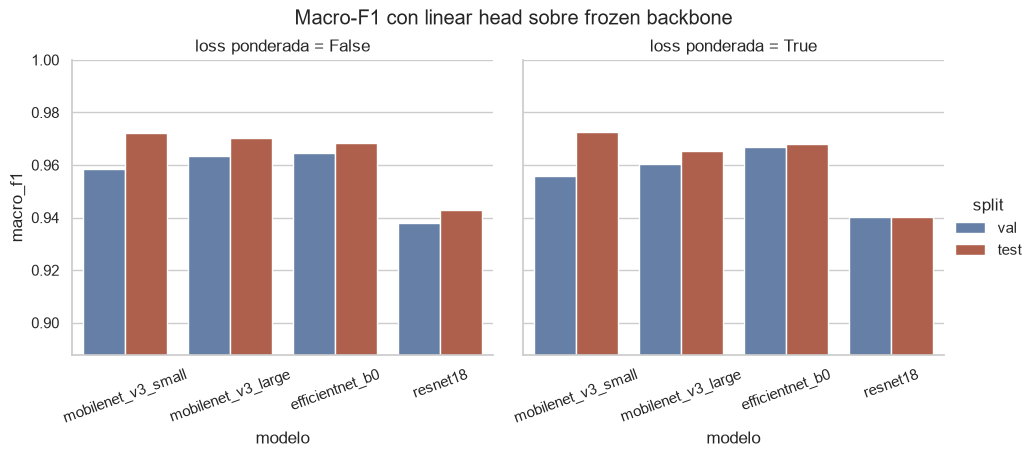

Mejor por macro-F1 en val: efficientnet_b0 (ponderada=True) -> val 0.9667 | test 0.9682


In [4]:
plot = res.melt(id_vars=["modelo", "loss ponderada"], value_vars=["val_macro_f1", "test_macro_f1"],
                var_name="split", value_name="macro_f1")
plot["split"] = plot["split"].str.replace("_macro_f1", "")
g = sns.catplot(data=plot, x="modelo", y="macro_f1", hue="split", col="loss ponderada",
                kind="bar", height=4, aspect=1.2, palette=["#5b7db1", "#c0563b"])
g.set_xticklabels(rotation=20); g.set(ylim=(max(0, plot.macro_f1.min() - 0.05), 1))
g.figure.suptitle("Macro-F1 con linear head sobre frozen backbone", y=1.03)
plt.show()

best_row = res.sort_values("val_macro_f1", ascending=False).iloc[0]
BEST_MODEL, BEST_W = best_row["modelo"], bool(best_row["loss ponderada"])
print(f"Mejor por macro-F1 en val: {BEST_MODEL} (ponderada={BEST_W}) -> val {best_row.val_macro_f1:.4f} | test {best_row.test_macro_f1:.4f}")

**A completar por el equipo:** ¿la ponderación de clases ayuda a macro-F1 o solo mueve la métrica entre clases? ¿La diferencia entre arquitecturas es mayor que la diferencia entre val y test (ruido)? Un modelo 10× más pequeño que rinde parecido suele ser la mejor opción para un sistema de monitoreo real.

## 4. Análisis por clase del mejor modelo

Precision, recall y F1 por clase (sobre **test**). El accuracy global esconde qué enfermedades cuestan más.

In [5]:
pred = preds[(BEST_MODEL, BEST_W)]
yt, yp = y[idx["test"]], pred[idx["test"]]
short = [c.replace("__", "_").replace("_", " ") for c in classes]
rep = pd.DataFrame(classification_report(yt, yp, target_names=short, output_dict=True, zero_division=0)).T
rep.loc[short].sort_values("f1-score").round(3)

,precision,recall,f1-score,support
Tomato Early blight,0.947,0.867,0.905,143.0
Tomato Target Spot,0.922,0.940,0.931,201.0
Tomato Spider mites Two spotted spider mite,0.946,0.954,0.950,239.0
Tomato Septoria leaf spot,0.950,0.972,0.961,253.0
Tomato Leaf Mold,0.963,0.963,0.963,136.0
Tomato Late blight,0.970,0.963,0.967,272.0
Tomato Bacterial spot,0.968,0.980,0.974,304.0
Tomato Tomato YellowLeaf Curl Virus,0.983,0.967,0.975,120.0
Potato Late blight,0.986,0.979,0.982,143.0
Pepper bell Bacterial spot,0.979,0.986,0.983,143.0


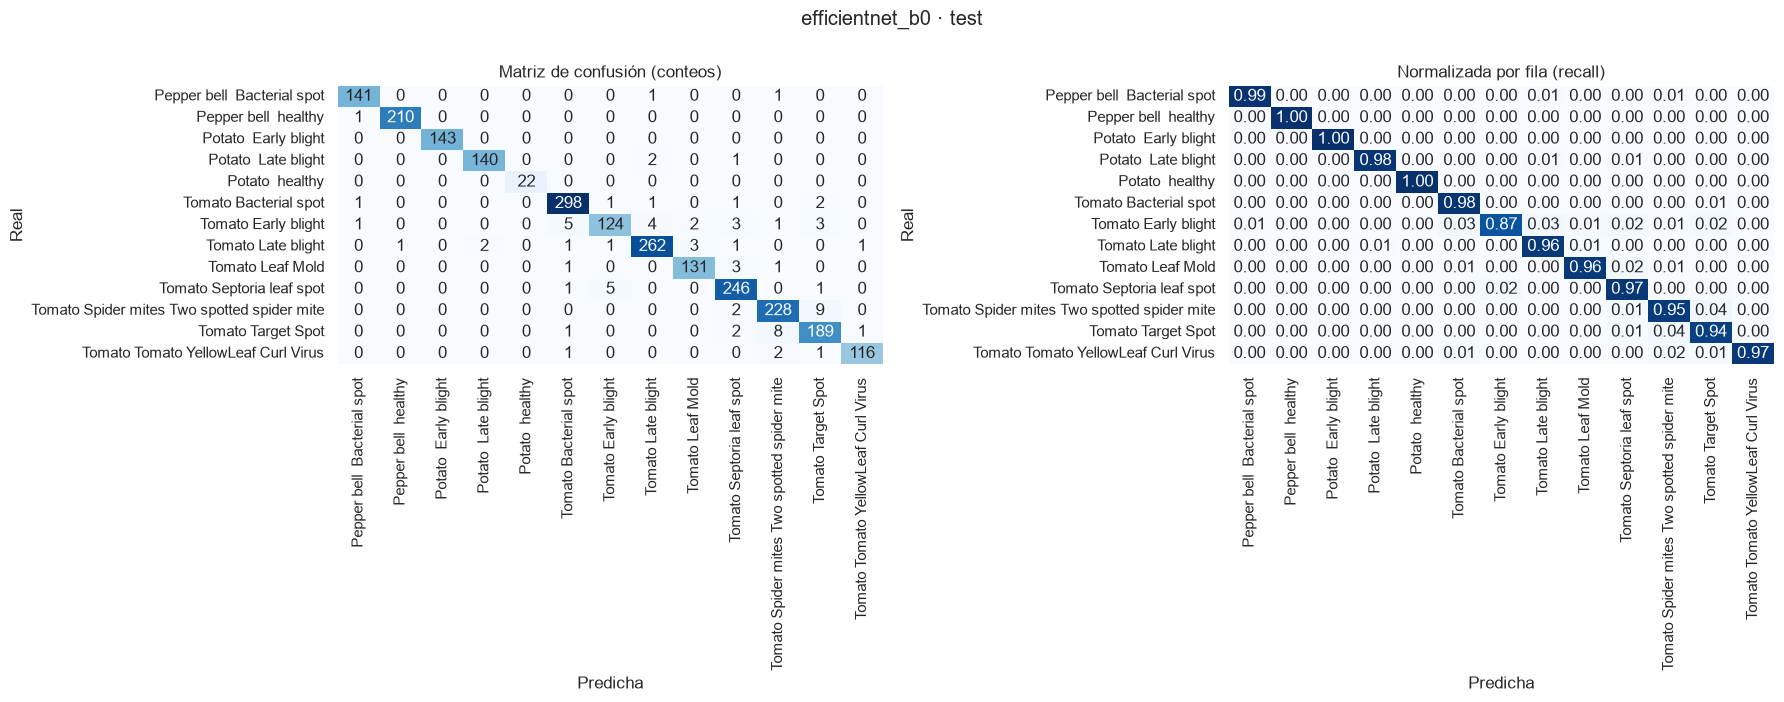

,real,predicha,errores
0,Tomato Spider mites Two spotted spider mite,Tomato Target Spot,9
1,Tomato Target Spot,Tomato Spider mites Two spotted spider mite,8
2,Tomato Early blight,Tomato Bacterial spot,5
3,Tomato Septoria leaf spot,Tomato Early blight,5
4,Tomato Early blight,Tomato Late blight,4
5,Tomato Early blight,Tomato Septoria leaf spot,3
6,Tomato Early blight,Tomato Target Spot,3
7,Tomato Late blight,Tomato Leaf Mold,3


In [6]:
cm = confusion_matrix(yt, yp)
cmn = cm / cm.sum(1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[0], cbar=False)
axes[0].set_title("Matriz de confusión (conteos)")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=short, yticklabels=short, ax=axes[1], cbar=False)
axes[1].set_title("Normalizada por fila (recall)")
for ax in axes:
    ax.set_xlabel("Predicha"); ax.set_ylabel("Real"); ax.tick_params(axis="x", rotation=90)
plt.suptitle(f"{BEST_MODEL} · test", y=1.0); plt.tight_layout(); plt.show()

pairs = [(short[i], short[j], int(cm[i, j])) for i in range(len(short)) for j in range(len(short)) if i != j and cm[i, j] > 0]
top = pd.DataFrame(sorted(pairs, key=lambda t: -t[2])[:8], columns=["real", "predicha", "errores"])
top

**A completar por el equipo:** ¿los errores más frecuentes ocurren dentro de una misma especie (enfermedades parecidas) o entre especies? ¿Coinciden con lo que se vio en las grillas de imágenes del EDA (síntomas visualmente similares, como *Early blight* vs *Late blight*)?

## 5. Espacio de embeddings (PCA)

Proyectamos los embeddings del mejor modelo a 2D para ver qué clases están bien separadas antes de entrenar nada.

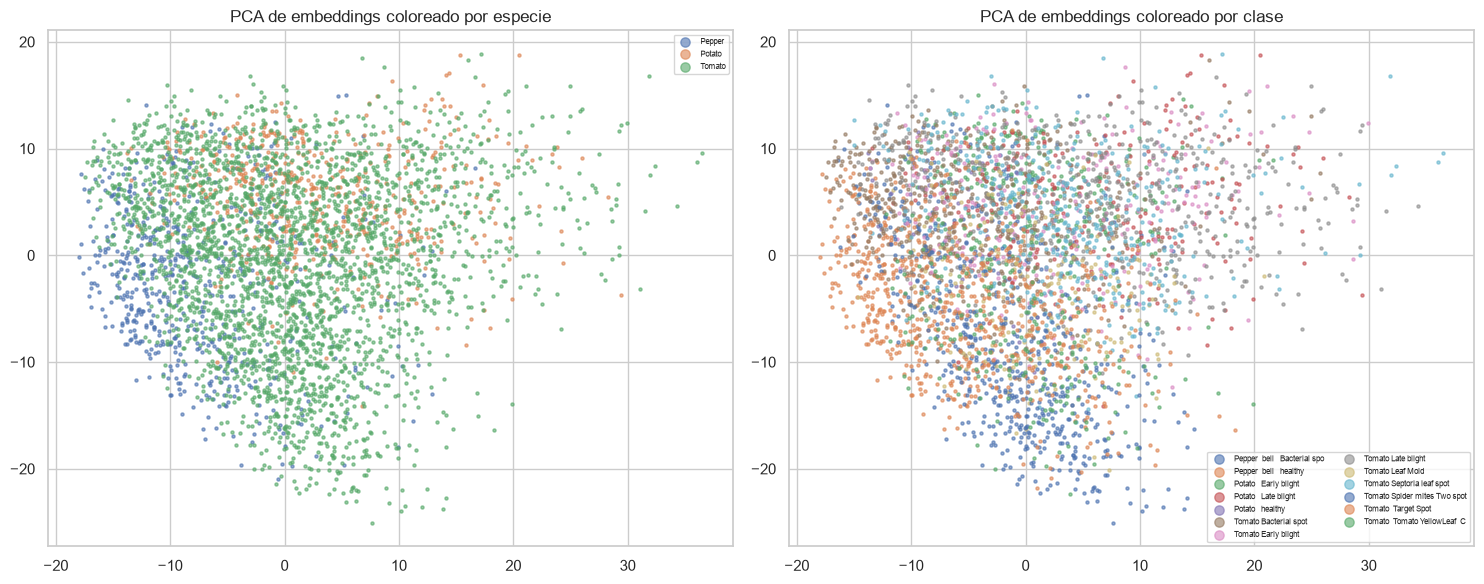

In [7]:
X = feats[BEST_MODEL]
sub = np.random.RandomState(SEED).choice(len(X), 4000, replace=False)
P = PCA(2, random_state=SEED).fit_transform((X[sub] - X[idx["train"]].mean(0)) / (X[idx["train"]].std(0) + 1e-6))
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, col, title in zip(axes, ["plant", "label"], ["Especie", "Clase"]):
    labs = df[col].values[sub]
    for l in sorted(set(labs)):
        m = labs == l
        ax.scatter(P[m, 0], P[m, 1], s=5, alpha=0.6, label=l.replace("_", " ")[:28])
    ax.set_title(f"PCA de embeddings coloreado por {title.lower()}"); ax.legend(markerscale=3, fontsize=6, ncol=1 if col == "plant" else 2)
plt.tight_layout(); plt.show()

## 6. Resumen y próximos pasos

- Guardamos la tabla completa en `results/linear_probe.csv`.
- Este es el **baseline** con frozen backbone y sin augmentation (los embeddings se extrajeron con `eval_tf`).

**Notebook 03 (fine-tuning + augmentation):** *unfreeze* de las últimas etapas de 1–2 arquitecturas elegidas acá (por costo/rendimiento) y comparar **con vs sin augmentation**, a resolución reducida si el tiempo en CPU lo exige. Luego, notebook de robustez (iluminación, rotación, escala, fondo).